In [2]:
# Importing necessary libraries
!pip install pandas numpy matplotlib sqlalchemy

import pandas as pd
import numpy as np
import sqlite3
from sqlite3 import Error
import matplotlib.pyplot as plt
from google.colab import files

### **Data Loading**

In [3]:
# Upload your dataset (CSV format)
uploaded = files.upload()

Saving sales_data.csv to sales_data.csv


In [5]:
file_name = list(uploaded.keys())[0]
df = pd.read_csv('sales_data.csv')

### **Data Inspection**

In [11]:
print("Data Overview:")
df.head()

Data Overview:


,date,warehouse,client_type,product_line,quantity,unit_price,total,payment
0,2021-06-01,Central,Retail,Miscellaneous,8,16.85,134.83,Credit card
1,2021-06-01,North,Retail,Breaking system,9,19.29,173.61,Cash
2,2021-06-01,North,Retail,Suspension & traction,8,32.93,263.45,Credit card
3,2021-06-01,North,Wholesale,Frame & body,16,37.84,605.44,Transfer
4,2021-06-01,Central,Retail,Engine,2,60.48,120.96,Credit card


In [12]:
# Validate data
print("\nData Structure:")
print(df.info())
print("Data Dimensions:", df.shape)
print("\nColumn Overview:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())


Data Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1000 non-null   object 
 1   warehouse     1000 non-null   object 
 2   client_type   1000 non-null   object 
 3   product_line  1000 non-null   object 
 4   quantity      1000 non-null   int64  
 5   unit_price    1000 non-null   float64
 6   total         1000 non-null   float64
 7   payment       1000 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 62.6+ KB
None
Data Dimensions: (1000, 8)

Column Overview:
date             object
warehouse        object
client_type      object
product_line     object
quantity          int64
unit_price      float64
total           float64
payment          object
dtype: object

Missing Values:
date            0
warehouse       0
client_type     0
product_line    0
quantity        0
unit_price      0
tota

### **Setup SQLite**

In [13]:
# Create in-memory SQLite database
conn = sqlite3.connect(':memory:')

# Load DataFrame to SQL table named 'sales'
df.to_sql('sales', conn, index=False, if_exists='replace')

# Verify table creation
try:
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    print("\nTables in Database:", cursor.fetchall())
    cursor.execute("PRAGMA table_info(sales);")
    print("\nTable Schema:", cursor.fetchall())
except Error as e:
    print("SQL Error:", e)


Tables in Database: [('sales',)]

Table Schema: [(0, 'date', 'TEXT', 0, None, 0), (1, 'warehouse', 'TEXT', 0, None, 0), (2, 'client_type', 'TEXT', 0, None, 0), (3, 'product_line', 'TEXT', 0, None, 0), (4, 'quantity', 'INTEGER', 0, None, 0), (5, 'unit_price', 'REAL', 0, None, 0), (6, 'total', 'REAL', 0, None, 0), (7, 'payment', 'TEXT', 0, None, 0)]


### **Revenue Analysis Query**

In [14]:
# Complex SQL Query for Net Revenue Analysis
sql_query = """
SELECT
    date,
    warehouse,
    product_line,
    ROUND(SUM(total), 2) AS net_revenue
FROM sales
GROUP BY date, warehouse, product_line
ORDER BY date DESC, net_revenue DESC;
"""

# Execute and fetch results
revenue_df = pd.read_sql_query(sql_query, conn)
print("\nTop 10 Revenue Records:")
print(revenue_df.head(10))


Top 10 Revenue Records:
         date warehouse           product_line  net_revenue
0  2021-08-28   Central      Electrical system      1216.20
1  2021-08-28      West          Miscellaneous       813.44
2  2021-08-28      West      Electrical system       563.85
3  2021-08-28     North      Electrical system       548.13
4  2021-08-28     North           Frame & body       521.50
5  2021-08-28      West        Breaking system       320.96
6  2021-08-28   Central          Miscellaneous       231.20
7  2021-08-28     North  Suspension & traction       184.42
8  2021-08-27   Central                 Engine      2146.47
9  2021-08-27   Central      Electrical system       504.30


### **cumulative revenue per warehouse**

In [15]:
# Calculate cumulative revenue per warehouse
cumulative_sql = """
SELECT
    date,
    warehouse,
    SUM(net_revenue) OVER (
        PARTITION BY warehouse
        ORDER BY date
    ) AS cumulative_revenue
FROM (
    SELECT
        date,
        warehouse,
        SUM(total) AS net_revenue
    FROM sales
    GROUP BY date, warehouse
)
ORDER BY warehouse, date;
"""

cumulative_df = pd.read_sql_query(cumulative_sql, conn)

### **Visualizations**

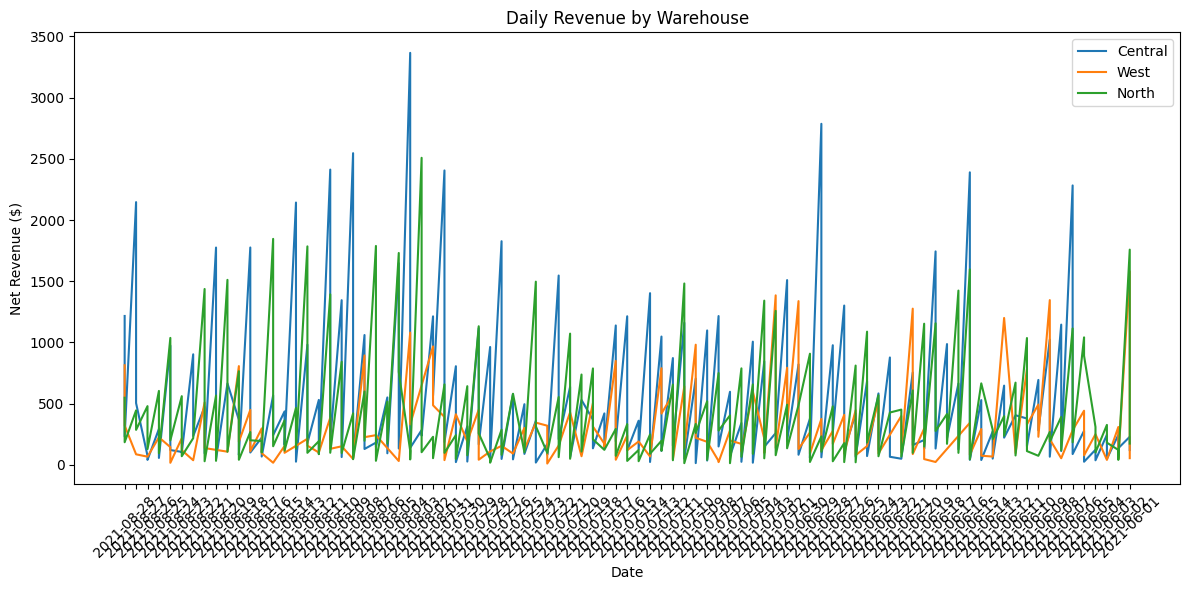

In [16]:
# Daily Revenue Trend
plt.figure(figsize=(12, 6))
for warehouse in revenue_df['warehouse'].unique():
    wh_data = revenue_df[revenue_df['warehouse'] == warehouse]
    plt.plot(wh_data['date'], wh_data['net_revenue'], label=warehouse)

plt.title('Daily Revenue by Warehouse')
plt.xlabel('Date')
plt.ylabel('Net Revenue ($)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

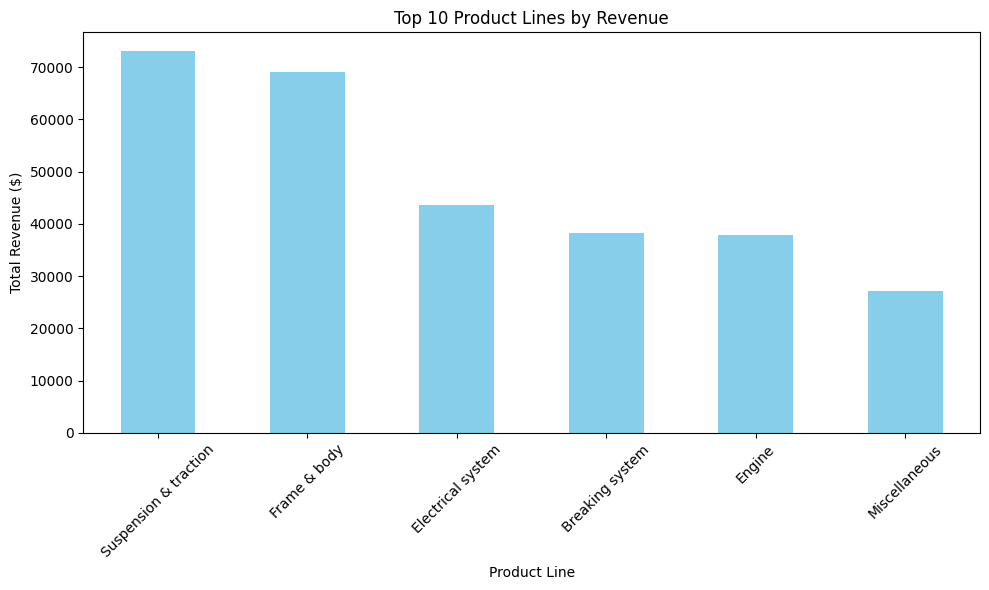

In [17]:
# Product Line Performance (Top 10)
top_products = revenue_df.groupby('product_line')['net_revenue'].sum().nlargest(10)
plt.figure(figsize=(10, 6))
top_products.plot(kind='bar', color='skyblue')
plt.title('Top 10 Product Lines by Revenue')
plt.xlabel('Product Line')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

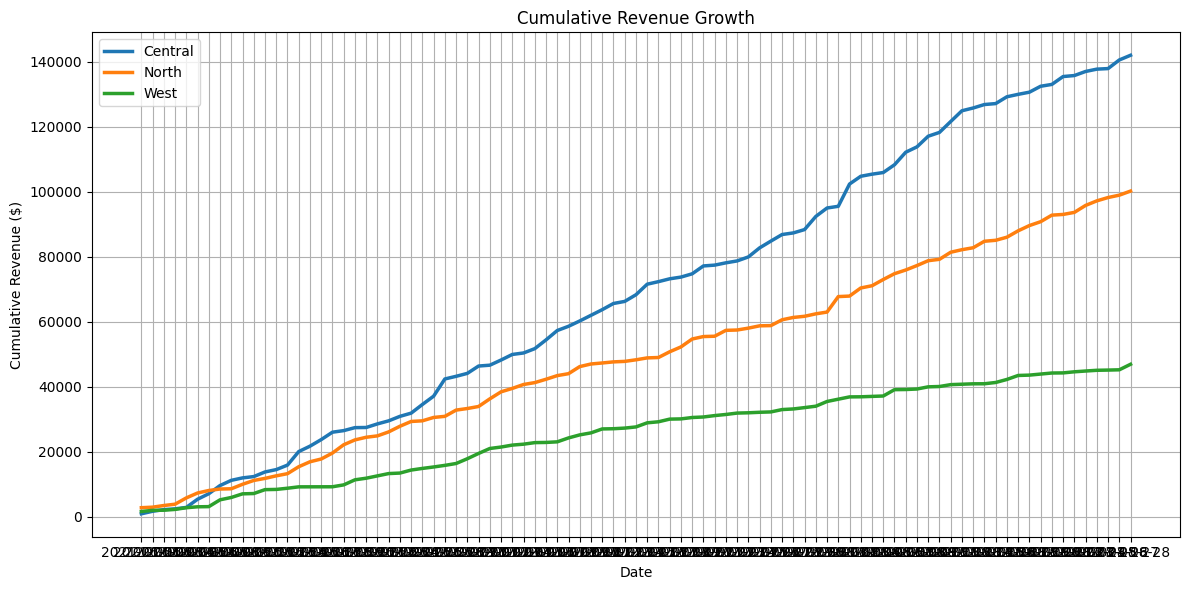

In [18]:
# Cumulative Revenue Growth
plt.figure(figsize=(12, 6))
for warehouse in cumulative_df['warehouse'].unique():
    wh_data = cumulative_df[cumulative_df['warehouse'] == warehouse]
    plt.plot(wh_data['date'], wh_data['cumulative_revenue'], label=warehouse, linewidth=2.5)

plt.title('Cumulative Revenue Growth')
plt.xlabel('Date')
plt.ylabel('Cumulative Revenue ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
# Export to CSV
revenue_df.to_csv('revenue_analysis_results.csv', index=False)
files.download('revenue_analysis_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>